In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

In [8]:
DATA_URL = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"

df = pd.read_csv(DATA_URL)

df.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

df.head()

,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22695 entries, 2013-12-02 21:15:00 to 2014-02-19 15:25:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   22695 non-null  float64
dtypes: float64(1)
memory usage: 354.6 KB


,value
count,22695.000000
mean,85.926498
std,13.746912
min,2.084721
25%,83.080078
50%,89.408246
75%,94.016252
max,108.510543


In [11]:
df.isna().sum()

,0
value,0


In [12]:
time_diff = df.index.to_series().diff().value_counts()
time_diff.head()

,count
timestamp,
0 days 00:05:00,22693
-1 days +23:05:00,1


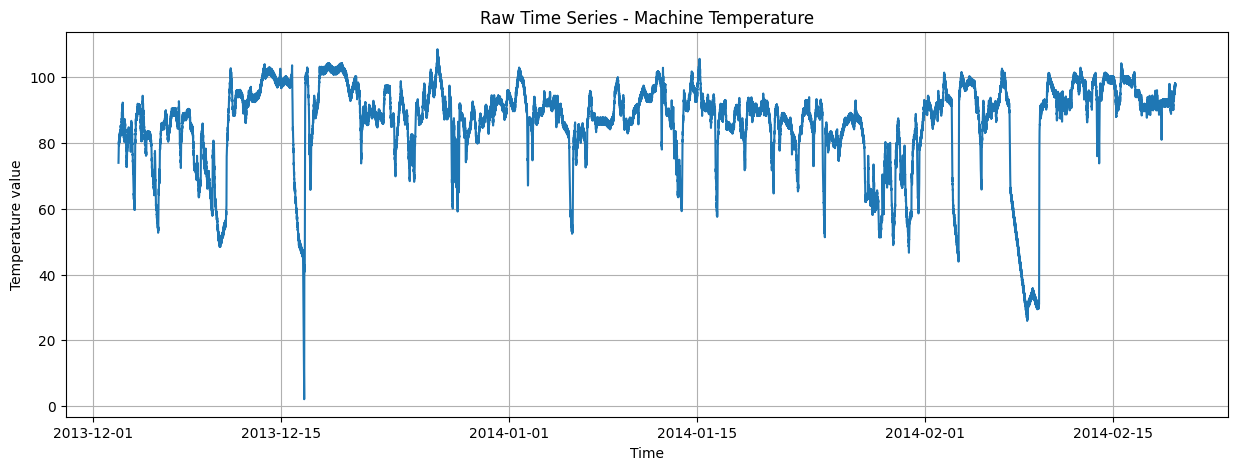

In [13]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df["value"])
plt.title("Raw Time Series - Machine Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature value")
plt.grid(True)
plt.show()

In [14]:
values = df["value"]

mean_value = values.mean()
std_value = values.std()
min_value = values.min()
max_value = values.max()
skewness = stats.skew(values)

stats_summary = pd.DataFrame({
    "metric": ["mean", "std", "min", "max", "skewness"],
    "value": [mean_value, std_value, min_value, max_value, skewness]
})

stats_summary

,metric,value
0,mean,85.926498
1,std,13.746912
2,min,2.084721
3,max,108.510543
4,skewness,-1.833686


Skewness = -1.8 cho thấy machine temperature bị left-skewed nặng, không phải Gaussian. Vì vậy không nên dùng global 3σ trực tiếp. Với detector statistical, IQR hoặc STL + IQR sẽ phù hợp hơn, đặc biệt nếu ACF cho thấy có seasonal pattern.

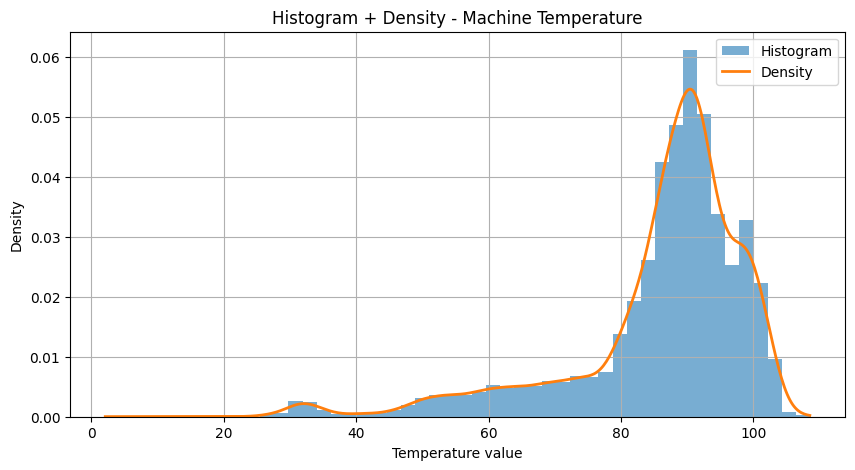

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(values, bins=50, density=True, alpha=0.6, label="Histogram")

# KDE density
kde = stats.gaussian_kde(values)
x_range = np.linspace(values.min(), values.max(), 500)
plt.plot(x_range, kde(x_range), linewidth=2, label="Density")

plt.title("Histogram + Density - Machine Temperature")
plt.xlabel("Temperature value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

Data không Gaussian vì phân phối không có dạng chuông đối xứng quanh mean. Data bị skewed nặng, cụ thể là left-skewed vì skewness = -1.8. Điều này nghĩa là đa số giá trị nằm ở vùng cao, nhưng có một số giá trị thấp bất thường kéo đuôi phân phối sang bên trái.

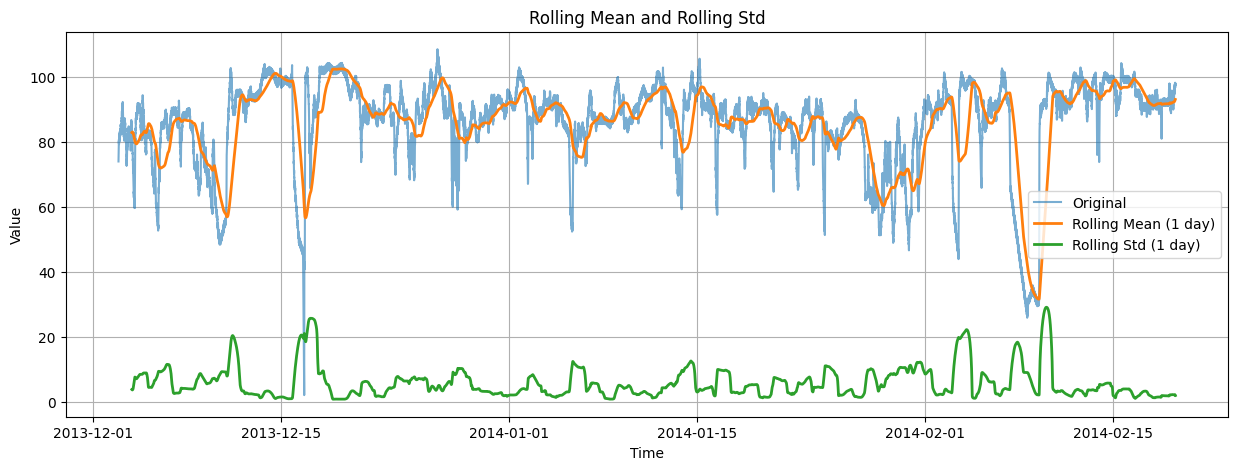

In [16]:
window = 288  # 1 ngày vì data mỗi 5 phút

rolling_mean = values.rolling(window=window).mean()
rolling_std = values.rolling(window=window).std()

plt.figure(figsize=(15, 5))
plt.plot(values, label="Original", alpha=0.6)
plt.plot(rolling_mean, label="Rolling Mean (1 day)", linewidth=2)
plt.plot(rolling_std, label="Rolling Std (1 day)", linewidth=2)

plt.title("Rolling Mean and Rolling Std")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

Data có dấu hiệu non-stationary. Rolling mean thay đổi theo từng giai đoạn và rolling std cũng biến động mạnh, đặc biệt tại các đoạn có spike/drop. Vì vậy, global 3σ không phù hợp. Nếu dùng statistical detector thì nên dùng rolling window, IQR, hoặc STL nếu ACF cho thấy có seasonal pattern.

Dataset này vừa bị left-skewed nặng với skewness = -1.8, vừa không hoàn toàn stationary theo rolling mean/std. Vì vậy không nên dùng global Z-score/3σ trực tiếp. IQR phù hợp hơn vì robust với skew/outlier. Nếu ACF phát hiện seasonal rõ, nên dùng STL để tách trend/seasonal trước rồi detect anomaly trên residual.

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

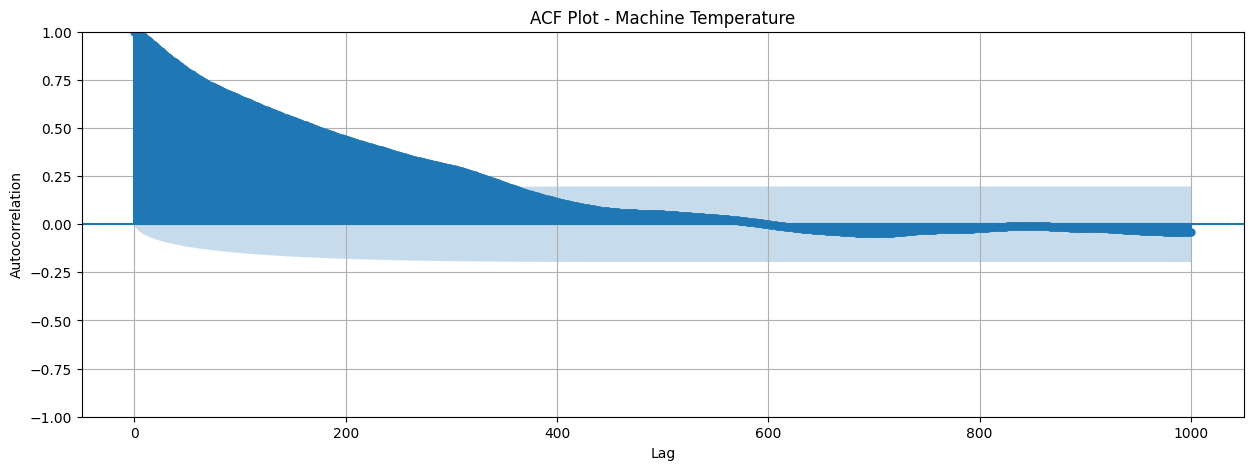

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))
plot_acf(values, lags=1000, ax=ax)
plt.title("ACF Plot - Machine Temperature")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

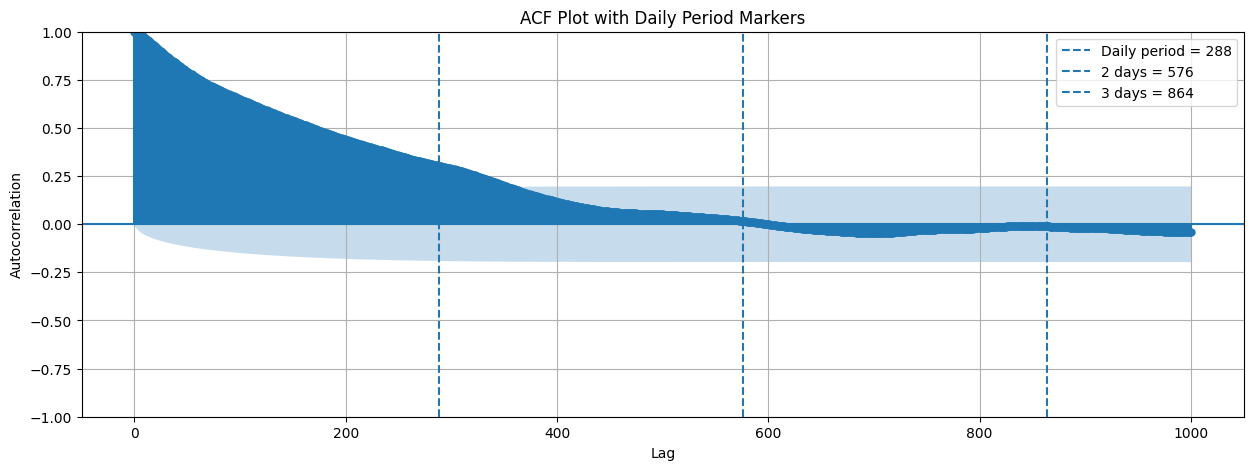

In [20]:
fig, ax = plt.subplots(figsize=(15, 5))
plot_acf(values, lags=1000, ax=ax)

ax.axvline(288, linestyle="--", label="Daily period = 288")
ax.axvline(576, linestyle="--", label="2 days = 576")
ax.axvline(864, linestyle="--", label="3 days = 864")

plt.title("ACF Plot with Daily Period Markers")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.legend()
plt.grid(True)
plt.show()

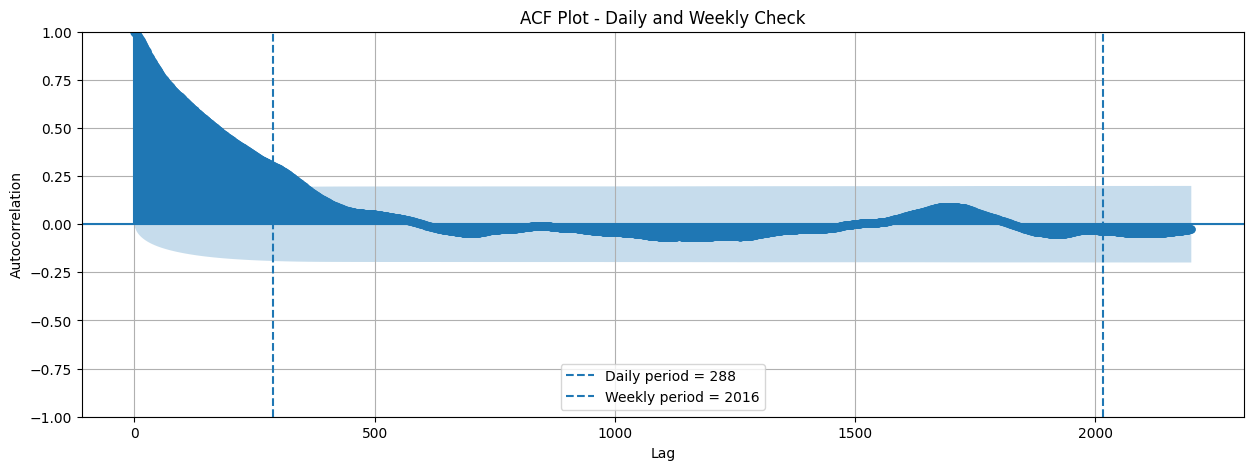

In [21]:
fig, ax = plt.subplots(figsize=(15, 5))
plot_acf(values, lags=2200, ax=ax)

ax.axvline(288, linestyle="--", label="Daily period = 288")
ax.axvline(2016, linestyle="--", label="Weekly period = 2016")

plt.title("ACF Plot - Daily and Weekly Check")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.legend()
plt.grid(True)
plt.show()

Dataset machine temperature là univariate time series, được ghi mỗi 5 phút. Histogram + density cho thấy data không Gaussian và bị left-skewed nặng với skewness = -1.8. Rolling mean và rolling std thay đổi theo thời gian, nên data không hoàn toàn stationary. ACF không có peak rõ tại lag 288 hoặc 2016, nên chưa có bằng chứng về daily/weekly seasonality mạnh. Vì vậy, Detector 1 nên ưu tiên IQR hoặc rolling IQR vì robust hơn với skewed data và outlier; không nên dùng global 3σ trực tiếp.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def detect_iqr(series, k=1.5):
    """
    Detect anomalies using IQR.

    IQR phù hợp với skewed data vì dùng Q1, Q3 và median-based range,
    không phụ thuộc vào mean/std như Z-score.

    Args:
        series: pandas Series hoặc array-like
        k: IQR multiplier, thường dùng 1.5
           tăng k -> ít anomaly hơn
           giảm k -> nhạy hơn, nhiều anomaly hơn

    Returns:
        anomalies: boolean Series, True = anomaly
        lower: lower threshold
        upper: upper threshold
    """
    s = pd.Series(series).dropna()

    Q1 = np.percentile(s, 25)
    Q3 = np.percentile(s, 75)
    IQR = Q3 - Q1

    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    anomalies = (series < lower) | (series > upper)

    return anomalies, lower, upper

In [23]:
values = df["value"]

iqr_anomalies, lower, upper = detect_iqr(values, k=1.5)

print(f"Lower threshold: {lower:.4f}")
print(f"Upper threshold: {upper:.4f}")
print(f"Number of anomalies: {iqr_anomalies.sum()}")
print(f"Anomaly rate: {iqr_anomalies.mean() * 100:.2f}%")

Lower threshold: 66.6758
Upper threshold: 110.4205
Number of anomalies: 2298
Anomaly rate: 10.13%


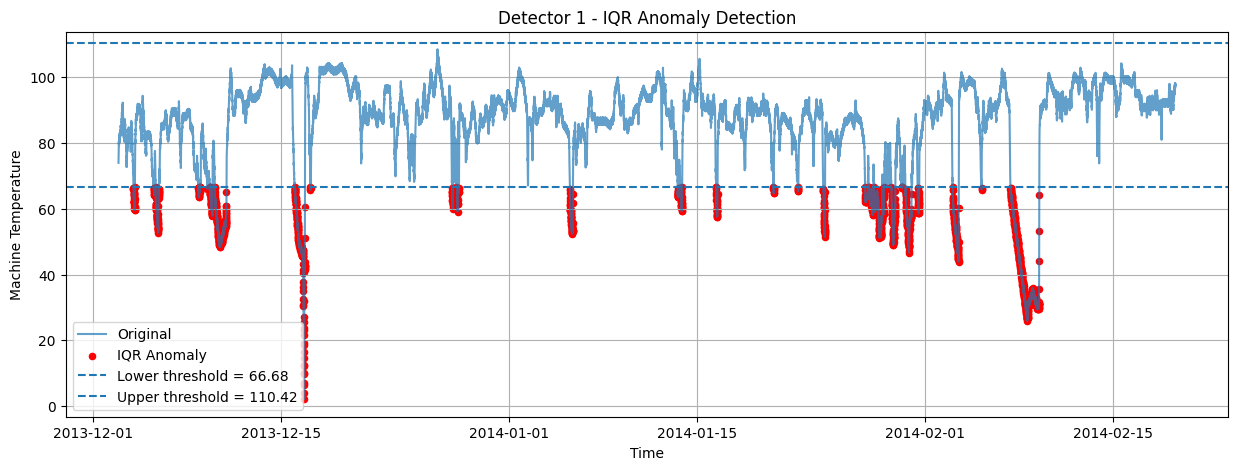

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, values, label="Original", alpha=0.7)

plt.scatter(
    df.index[iqr_anomalies],
    values[iqr_anomalies],
    color="red",
    label="IQR Anomaly",
    s=20
)

plt.axhline(lower, linestyle="--", label=f"Lower threshold = {lower:.2f}")
plt.axhline(upper, linestyle="--", label=f"Upper threshold = {upper:.2f}")

plt.title("Detector 1 - IQR Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Machine Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
for k in [1.0, 1.5, 2.0]:
    anomalies, lower, upper = detect_iqr(values, k=k)

    print("=" * 40)
    print(f"IQR k = {k}")
    print(f"Lower threshold: {lower:.4f}")
    print(f"Upper threshold: {upper:.4f}")
    print(f"Number of anomalies: {anomalies.sum()}")
    print(f"Anomaly rate: {anomalies.mean() * 100:.2f}%")

IQR k = 1.0
Lower threshold: 72.1439
Upper threshold: 104.9524
Number of anomalies: 3021
Anomaly rate: 13.31%
IQR k = 1.5
Lower threshold: 66.6758
Upper threshold: 110.4205
Number of anomalies: 2298
Anomaly rate: 10.13%
IQR k = 2.0
Lower threshold: 61.2077
Upper threshold: 115.8886
Number of anomalies: 1677
Anomaly rate: 7.39%


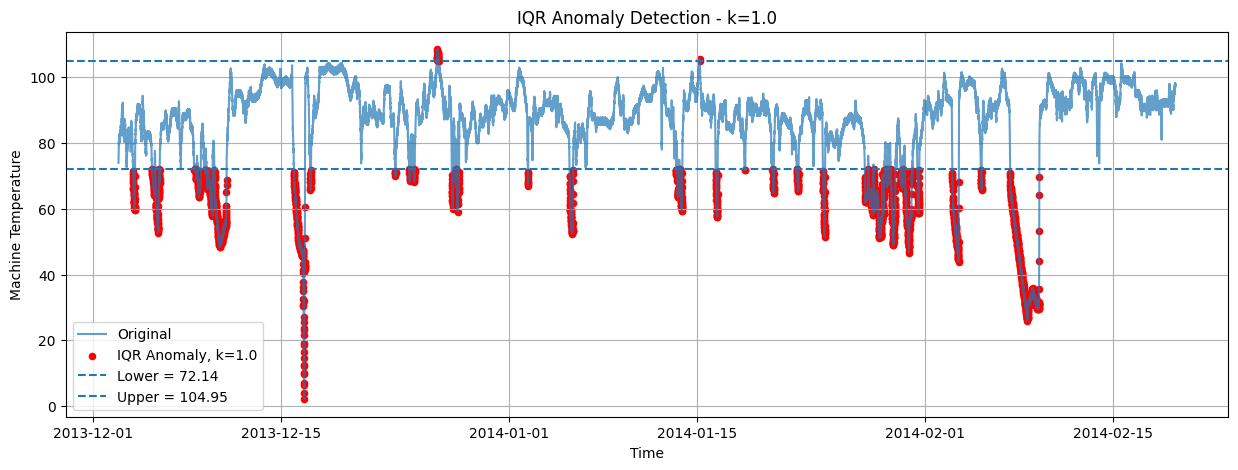

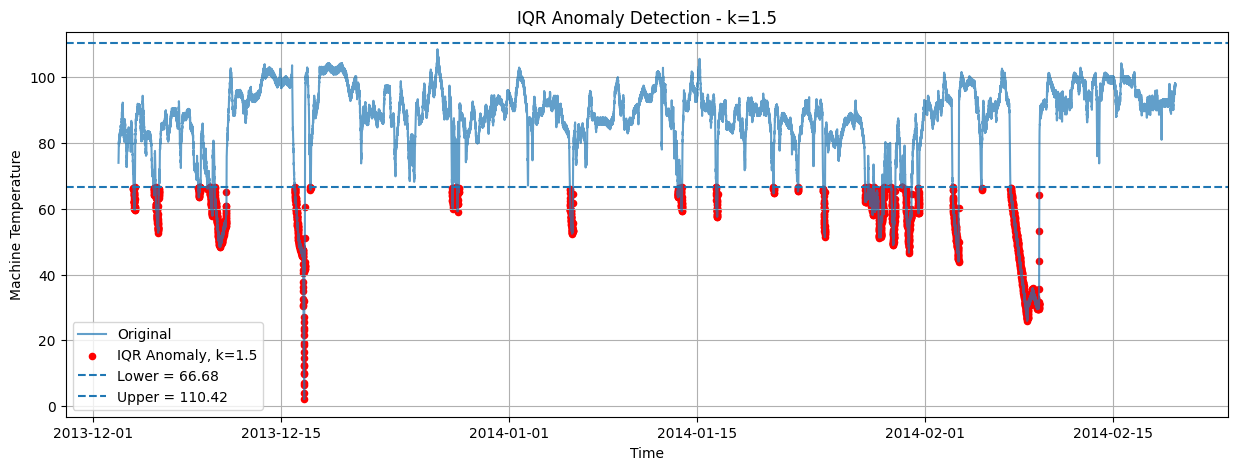

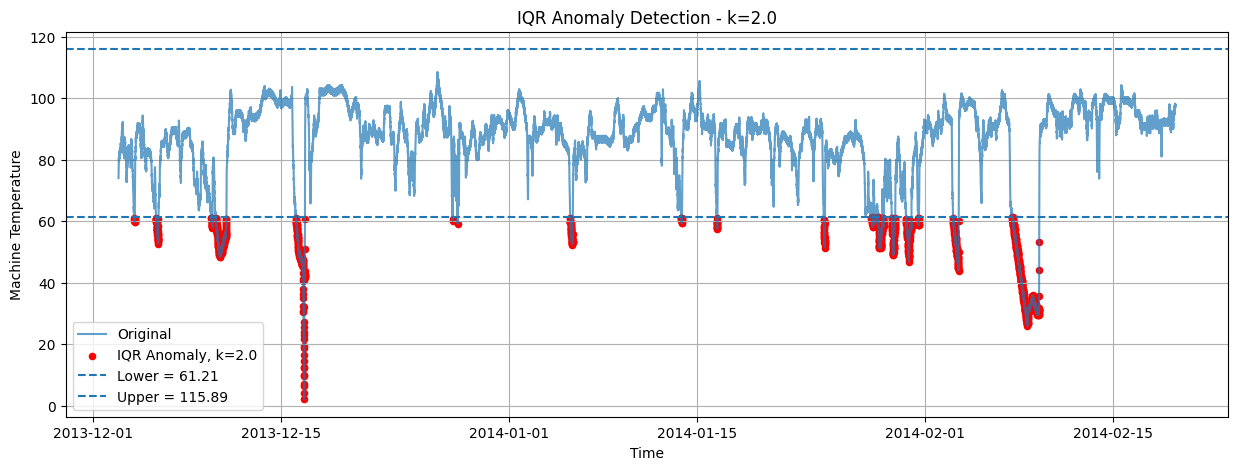

In [26]:
k_values = [1.0, 1.5, 2.0]

for k in k_values:
    anomalies, lower, upper = detect_iqr(values, k=k)

    plt.figure(figsize=(15, 5))

    plt.plot(df.index, values, label="Original", alpha=0.7)

    plt.scatter(
        df.index[anomalies],
        values[anomalies],
        color="red",
        label=f"IQR Anomaly, k={k}",
        s=20
    )

    plt.axhline(lower, linestyle="--", label=f"Lower = {lower:.2f}")
    plt.axhline(upper, linestyle="--", label=f"Upper = {upper:.2f}")

    plt.title(f"IQR Anomaly Detection - k={k}")
    plt.xlabel("Time")
    plt.ylabel("Machine Temperature")
    plt.legend()
    plt.grid(True)
    plt.show()

Detector 1 được chọn là IQR vì data bị left-skewed nặng với skewness = -1.8. Data không Gaussian và không có seasonal pattern rõ ràng trên ACF, nên Rolling Z-score và STL không phải lựa chọn tốt nhất. IQR phù hợp hơn vì robust với skewed data và outlier, không phụ thuộc trực tiếp vào mean/std.

In [27]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import joblib
import json
import urllib.request

In [28]:
LABEL_URL = "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_windows.json"
FILE_KEY = "realKnownCause/machine_temperature_system_failure.csv"

with urllib.request.urlopen(LABEL_URL) as response:
    label_windows = json.load(response)

windows = label_windows[FILE_KEY]
windows

[['2013-12-10 06:25:00.000000', '2013-12-12 05:35:00.000000'],
 ['2013-12-15 17:50:00.000000', '2013-12-17 17:00:00.000000'],
 ['2014-01-27 14:20:00.000000', '2014-01-29 13:30:00.000000'],
 ['2014-02-07 14:55:00.000000', '2014-02-09 14:05:00.000000']]

In [29]:
df["label"] = 0

for start, end in windows:
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    df.loc[(df.index >= start) & (df.index <= end), "label"] = 1

print(df["label"].value_counts())

label
0    20427
1     2268
Name: count, dtype: int64


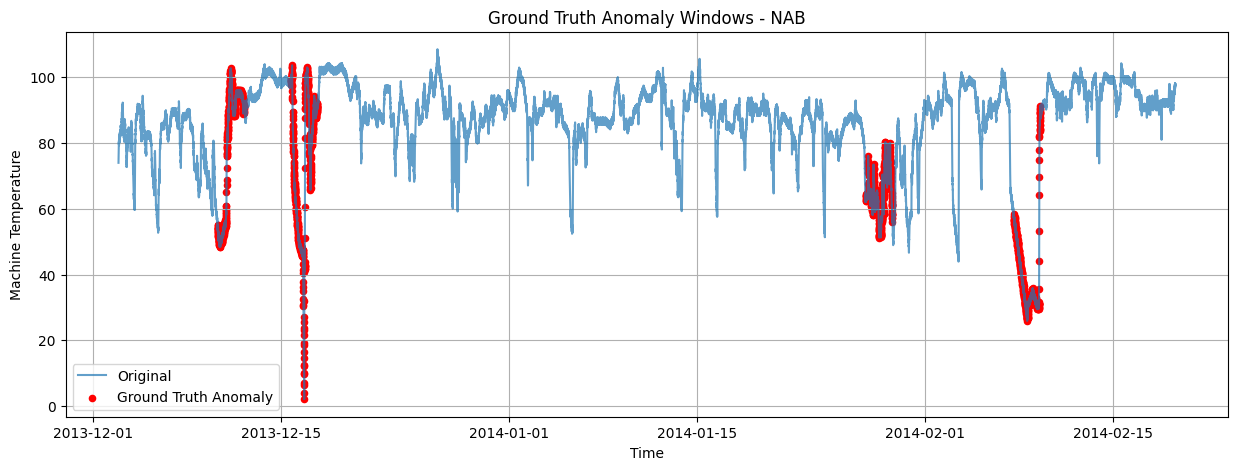

In [30]:
plt.figure(figsize=(15, 5))

plt.plot(df.index, df["value"], label="Original", alpha=0.7)

plt.scatter(
    df.index[df["label"] == 1],
    df.loc[df["label"] == 1, "value"],
    color="red",
    s=20,
    label="Ground Truth Anomaly"
)

plt.title("Ground Truth Anomaly Windows - NAB")
plt.xlabel("Time")
plt.ylabel("Machine Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
values = df["value"]

iqr_anomalies, lower, upper = detect_iqr(values, k=1.5)

df["iqr_pred"] = iqr_anomalies.astype(int)

print(f"IQR lower threshold: {lower:.4f}")
print(f"IQR upper threshold: {upper:.4f}")
print(f"IQR detected anomalies: {df['iqr_pred'].sum()}")

IQR lower threshold: 66.6758
IQR upper threshold: 110.4205
IQR detected anomalies: 2298


In [32]:
y_true = df["label"]
y_pred_iqr = df["iqr_pred"]

iqr_precision = precision_score(y_true, y_pred_iqr, zero_division=0)
iqr_recall = recall_score(y_true, y_pred_iqr, zero_division=0)
iqr_f1 = f1_score(y_true, y_pred_iqr, zero_division=0)

print("IQR Metrics")
print(f"Precision: {iqr_precision:.4f}")
print(f"Recall: {iqr_recall:.4f}")
print(f"F1: {iqr_f1:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred_iqr))

IQR Metrics
Precision: 0.5801
Recall: 0.5877
F1: 0.5839
Confusion matrix:
[[19462   965]
 [  935  1333]]


In [33]:
def build_features(df, value_col="value"):
    """
    Build time-series feature table for Isolation Forest.

    Data interval = 5 minutes:
    - 1 hour = 12 points
    - 4 hours = 48 points
    - 1 day = 288 points
    """

    s = df[value_col]

    window_1h = 12
    window_4h = 48
    window_1d = 288

    features = pd.DataFrame(index=df.index)

    features["value"] = s
    features["rolling_mean_1h"] = s.rolling(window_1h).mean()
    features["rolling_std_1h"] = s.rolling(window_1h).std()
    features["rolling_mean_4h"] = s.rolling(window_4h).mean()
    features["rolling_std_4h"] = s.rolling(window_4h).std()
    features["rolling_median_1d"] = s.rolling(window_1d).median()

    features["rate_of_change"] = s.diff()
    features["rate_of_change_1h"] = s.diff(window_1h)

    features["lag_1"] = s.shift(1)
    features["lag_12"] = s.shift(window_1h)
    features["lag_288"] = s.shift(window_1d)

    features["hour"] = df.index.hour
    features["day_of_week"] = df.index.dayofweek
    features["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

    rolling_std_safe = s.rolling(window_1h).std().replace(0, 1e-10)
    features["rolling_z_score_1h"] = (s - s.rolling(window_1h).mean()) / rolling_std_safe

    return features.dropna()

In [34]:
X = build_features(df)

display(X.head())
print(X.shape)

,value,rolling_mean_1h,rolling_std_1h,rolling_mean_4h,rolling_std_4h,rolling_median_1d,rate_of_change,rate_of_change_1h,lag_1,lag_12,lag_288,hour,day_of_week,is_weekend,rolling_z_score_1h
timestamp,,,,,,,,,,,,,,,
2013-12-03 21:15:00,84.332735,84.643005,0.880943,82.968196,2.343923,82.881141,0.879550,-0.159595,83.453184,84.492329,73.967322,21,1,0,-0.352202
2013-12-03 21:20:00,83.624800,84.563642,0.929002,82.987517,2.345465,82.930936,-0.707934,-0.952352,84.332735,84.577153,74.935882,21,1,0,-1.010592
2013-12-03 21:25:00,83.820248,84.372138,0.808427,83.020432,2.345842,82.984777,0.195447,-2.298047,83.624800,86.118294,76.124162,21,1,0,-0.682672
2013-12-03 21:30:00,82.821181,84.122760,0.784518,83.033731,2.342800,82.984777,-0.999066,-2.992535,83.820248,85.813716,78.140707,21,1,0,-1.659082
2013-12-03 21:35:00,82.485347,83.995457,0.916751,83.045712,2.338398,82.984777,-0.335834,-1.527638,82.821181,84.012985,79.329836,21,1,0,-1.647242


(22407, 15)


In [35]:
y_true_if = df.loc[X.index, "label"]

In [38]:
results = []

# Safely align y_true_if without index matching to avoid duplicate index explosion.
# X dropped exactly the first 288 rows (max window), so we take the last X.shape[0] rows.
y_true_if = df["label"].values[-X.shape[0]:]

for contamination in [0.01, 0.02, 0.05]:
    clf = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )

    clf.fit(X)

    pred = clf.predict(X)

    # Isolation Forest: -1 = anomaly, 1 = normal
    y_pred = (pred == -1).astype(int)

    precision = precision_score(y_true_if, y_pred, zero_division=0)
    recall = recall_score(y_true_if, y_pred, zero_division=0)
    f1 = f1_score(y_true_if, y_pred, zero_division=0)

    results.append({
        "contamination": contamination,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "detected_anomalies": y_pred.sum()
    })

    print("=" * 50)
    print(f"Isolation Forest contamination = {contamination}")
    print(f"Detected anomalies: {y_pred.sum()}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_true_if, y_pred))

results_df = pd.DataFrame(results)
display(results_df)

Isolation Forest contamination = 0.01
Detected anomalies: 225
Precision: 0.9956
Recall: 0.0988
F1: 0.1797
Confusion matrix:
[[20138     1]
 [ 2044   224]]
Isolation Forest contamination = 0.02
Detected anomalies: 449
Precision: 0.9399
Recall: 0.1861
F1: 0.3106
Confusion matrix:
[[20112    27]
 [ 1846   422]]
Isolation Forest contamination = 0.05
Detected anomalies: 1121
Precision: 0.6628
Recall: 0.3276
F1: 0.4385
Confusion matrix:
[[19761   378]
 [ 1525   743]]


,contamination,precision,recall,f1,detected_anomalies
0,0.01,0.995556,0.098765,0.179703,225
1,0.02,0.939866,0.186067,0.310637,449
2,0.05,0.662801,0.327601,0.438477,1121


In [39]:
best_row = results_df.sort_values("f1", ascending=False).iloc[0]
best_contamination = best_row["contamination"]

print(f"Best contamination by F1: {best_contamination}")

Best contamination by F1: 0.05


In [41]:
best_if_model = IsolationForest(
    n_estimators=200,
    contamination=best_contamination,
    random_state=42
)

best_if_model.fit(X)

if_pred = best_if_model.predict(X)
if_pred_binary = (if_pred == -1).astype(int)

# Create the full column by padding the start with zeros (for rows dropped by .dropna())
import numpy as np
df["if_pred"] = np.concatenate([np.zeros(len(df) - len(if_pred_binary), dtype=int), if_pred_binary])

print(df["if_pred"].value_counts())

if_pred
0    21574
1     1121
Name: count, dtype: int64


In [42]:
joblib.dump(best_if_model, "isolation_forest_machine_temperature.joblib")

['isolation_forest_machine_temperature.joblib']

In [43]:
y_pred_if = df.loc[X.index, "if_pred"]
y_true_if = df.loc[X.index, "label"]

if_precision = precision_score(y_true_if, y_pred_if, zero_division=0)
if_recall = recall_score(y_true_if, y_pred_if, zero_division=0)
if_f1 = f1_score(y_true_if, y_pred_if, zero_division=0)

comparison_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1", "Detected Anomalies"],
    "Detector 1 - IQR": [
        iqr_precision,
        iqr_recall,
        iqr_f1,
        int(df["iqr_pred"].sum())
    ],
    "Detector 2 - Isolation Forest": [
        if_precision,
        if_recall,
        if_f1,
        int(df["if_pred"].sum())
    ]
})

display(comparison_df)

,Metric,Detector 1 - IQR,Detector 2 - Isolation Forest
0,Precision,0.580070,0.662801
1,Recall,0.587743,0.327601
2,F1,0.583881,0.438477
3,Detected Anomalies,2298.000000,1121.000000


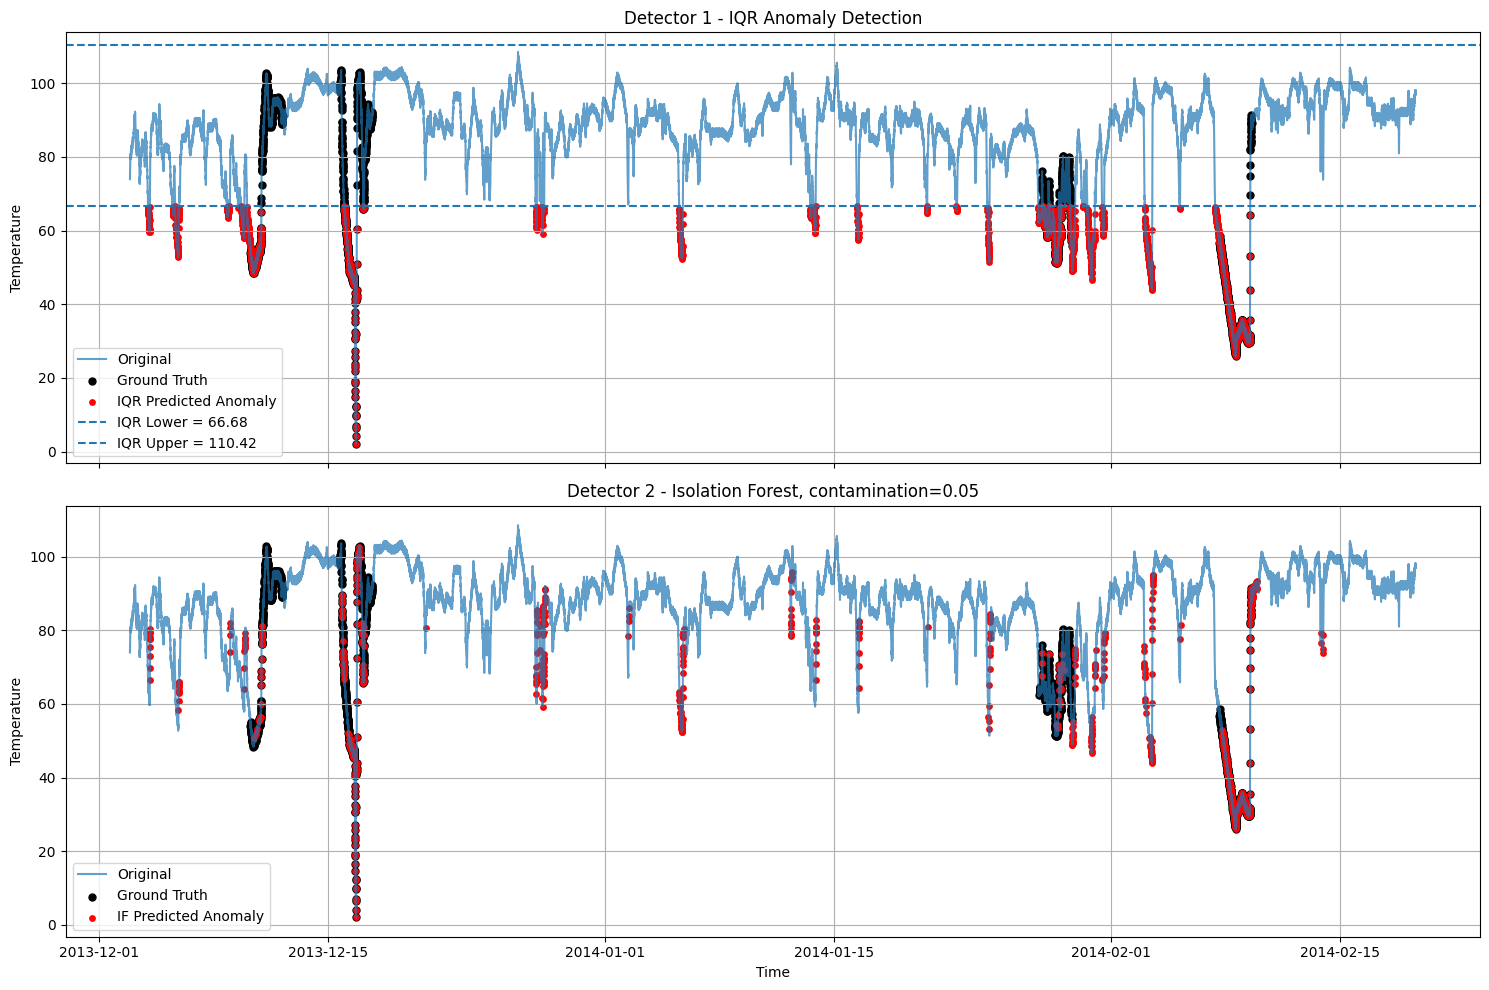

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Subplot 1: IQR
axes[0].plot(df.index, df["value"], label="Original", alpha=0.7)

axes[0].scatter(
    df.index[df["label"] == 1],
    df.loc[df["label"] == 1, "value"],
    color="black",
    s=25,
    label="Ground Truth"
)

axes[0].scatter(
    df.index[df["iqr_pred"] == 1],
    df.loc[df["iqr_pred"] == 1, "value"],
    color="red",
    s=15,
    label="IQR Predicted Anomaly"
)

axes[0].axhline(lower, linestyle="--", label=f"IQR Lower = {lower:.2f}")
axes[0].axhline(upper, linestyle="--", label=f"IQR Upper = {upper:.2f}")

axes[0].set_title("Detector 1 - IQR Anomaly Detection")
axes[0].set_ylabel("Temperature")
axes[0].legend()
axes[0].grid(True)


# Subplot 2: Isolation Forest
axes[1].plot(df.index, df["value"], label="Original", alpha=0.7)

axes[1].scatter(
    df.index[df["label"] == 1],
    df.loc[df["label"] == 1, "value"],
    color="black",
    s=25,
    label="Ground Truth"
)

axes[1].scatter(
    df.index[df["if_pred"] == 1],
    df.loc[df["if_pred"] == 1, "value"],
    color="red",
    s=15,
    label="IF Predicted Anomaly"
)

axes[1].set_title(f"Detector 2 - Isolation Forest, contamination={best_contamination}")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Temperature")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Detector 1 - IQR đạt Precision = 0.5801, Recall = 0.5877 và F1 = 0.5839. Detector 2 - Isolation Forest đạt Precision = 0.6628, Recall = 0.3276 và F1 = 0.4385.

Kết quả cho thấy Isolation Forest có precision cao hơn, nghĩa là các anomaly mà model này báo thường chính xác hơn. Tuy nhiên, recall của Isolation Forest thấp hơn nhiều, cho thấy model bỏ sót khá nhiều anomaly thật. Ngược lại, IQR phát hiện nhiều anomaly hơn và đạt recall cao hơn, dù precision thấp hơn một chút.

Vì F1-score của IQR cao hơn Isolation Forest, IQR là detector tốt hơn trong lần thử nghiệm này. Điều này cũng phù hợp với EDA: data bị left-skewed nặng với skewness = -1.8, không Gaussian và không có seasonal pattern rõ ràng, nên IQR là lựa chọn statistical baseline phù hợp.

IQR nhạy hơn, bắt nhiều anomaly hơn, recall cao hơn nhưng có nhiều false alarm hơn. Isolation Forest bảo thủ hơn, báo ít anomaly hơn, precision cao hơn nhưng recall thấp, tức là dễ miss anomaly thật.

In [45]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_detector(y_true, y_pred, detector_name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        "Detector": detector_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Alarms": fp,
        "Detected Anomalies": int(y_pred.sum()),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }

iqr_eval = evaluate_detector(
    y_true=df["label"],
    y_pred=df["iqr_pred"],
    detector_name="Detector 1 - IQR"
)

# IF chỉ chắc chắn đúng trên các dòng có feature X
if_eval = evaluate_detector(
    y_true=df.loc[X.index, "label"],
    y_pred=df.loc[X.index, "if_pred"],
    detector_name="Detector 2 - Isolation Forest"
)

eval_df = pd.DataFrame([iqr_eval, if_eval])
display(eval_df)

,Detector,Precision,Recall,F1,False Alarms,Detected Anomalies,TP,FP,FN,TN
0,Detector 1 - IQR,0.580070,0.587743,0.583881,965,2298,1333,965,935,19462
1,Detector 2 - Isolation Forest,0.662801,0.327601,0.438477,378,1121,743,378,1525,19785


In [47]:
comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1", "False Alarms"],
    "Detector 1": [
        iqr_eval["Precision"],
        iqr_eval["Recall"],
        iqr_eval["F1"],
        iqr_eval["False Alarms"]
    ],
    "Detector 2 (IF)": [
        if_eval["Precision"],
        if_eval["Recall"],
        if_eval["F1"],
        if_eval["False Alarms"]
    ]
})

display(comparison_table)

,Metric,Detector 1,Detector 2 (IF)
0,Precision,0.580070,0.662801
1,Recall,0.587743,0.327601
2,F1,0.583881,0.438477
3,False Alarms,965.000000,378.000000


In [48]:
iqr_tuning_results = []

for k in [1.0, 1.5, 2.0]:
    anomalies, lower, upper = detect_iqr(df["value"], k=k)
    y_pred = anomalies.astype(int)

    tn, fp, fn, tp = confusion_matrix(df["label"], y_pred).ravel()

    precision = precision_score(df["label"], y_pred, zero_division=0)
    recall = recall_score(df["label"], y_pred, zero_division=0)
    f1 = f1_score(df["label"], y_pred, zero_division=0)

    iqr_tuning_results.append({
        "k": k,
        "lower": lower,
        "upper": upper,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_alarms": fp,
        "detected_anomalies": int(y_pred.sum())
    })

    print("=" * 60)
    print(f"IQR k = {k}")
    print(f"Lower threshold: {lower:.4f}")
    print(f"Upper threshold: {upper:.4f}")
    print(f"Detected anomalies: {int(y_pred.sum())}")
    print(f"False alarms: {fp}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")

iqr_tuning_df = pd.DataFrame(iqr_tuning_results)
display(iqr_tuning_df)

IQR k = 1.0
Lower threshold: 72.1439
Upper threshold: 104.9524
Detected anomalies: 3021
False alarms: 1561
Precision: 0.4833
Recall: 0.6437
F1: 0.5521
IQR k = 1.5
Lower threshold: 66.6758
Upper threshold: 110.4205
Detected anomalies: 2298
False alarms: 965
Precision: 0.5801
Recall: 0.5877
F1: 0.5839
IQR k = 2.0
Lower threshold: 61.2077
Upper threshold: 115.8886
Detected anomalies: 1677
False alarms: 575
Precision: 0.6571
Recall: 0.4859
F1: 0.5587


,k,lower,upper,precision,recall,f1,false_alarms,detected_anomalies
0,1.0,72.143904,104.952425,0.483284,0.643739,0.552089,1561,3021
1,1.5,66.675817,110.420512,0.580070,0.587743,0.583881,965,2298
2,2.0,61.207730,115.888599,0.657126,0.485891,0.558682,575,1677


In [51]:
best_row = results_df.sort_values("f1", ascending=False).iloc[0]
best_contamination = best_row["contamination"]

best_if_model = IsolationForest(
    n_estimators=200,
    contamination=best_contamination,
    random_state=42
)

best_if_model.fit(X)

joblib.dump(best_if_model, "isolation_forest_machine_temperature.joblib")

print(f"Saved model with contamination={best_contamination}")

Saved model with contamination=0.05


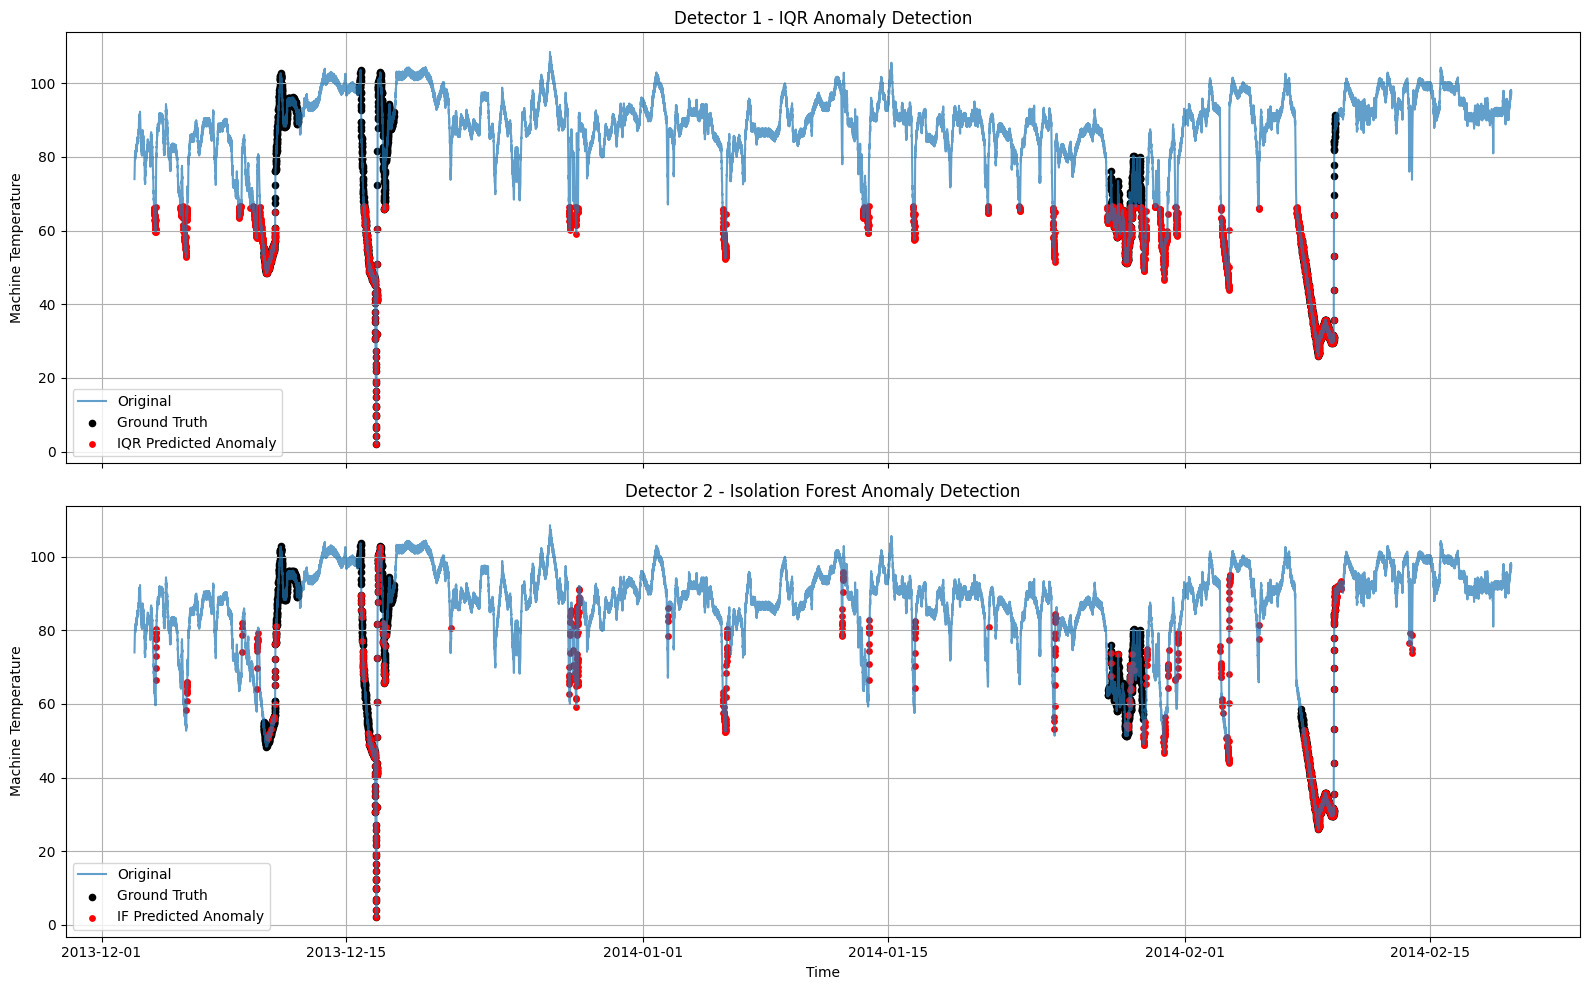

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Detector 1 - IQR
axes[0].plot(df.index, df["value"], label="Original", alpha=0.7)

axes[0].scatter(
    df.index[df["label"] == 1],
    df.loc[df["label"] == 1, "value"],
    color="black",
    s=20,
    label="Ground Truth"
)

axes[0].scatter(
    df.index[df["iqr_pred"] == 1],
    df.loc[df["iqr_pred"] == 1, "value"],
    color="red",
    s=15,
    label="IQR Predicted Anomaly"
)

axes[0].set_title("Detector 1 - IQR Anomaly Detection")
axes[0].set_ylabel("Machine Temperature")
axes[0].legend()
axes[0].grid(True)


# Detector 2 - Isolation Forest
axes[1].plot(df.index, df["value"], label="Original", alpha=0.7)

axes[1].scatter(
    df.index[df["label"] == 1],
    df.loc[df["label"] == 1, "value"],
    color="black",
    s=20,
    label="Ground Truth"
)

axes[1].scatter(
    df.index[df["if_pred"] == 1],
    df.loc[df["if_pred"] == 1, "value"],
    color="red",
    s=15,
    label="IF Predicted Anomaly"
)

axes[1].set_title("Detector 2 - Isolation Forest Anomaly Detection")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Machine Temperature")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

IQR là detector tốt hơn cho dataset này vì F1 và recall cao hơn. Isolation Forest có precision cao hơn nhưng recall thấp, nghĩa là báo ít hơn và đúng hơn, nhưng bỏ sót nhiều anomaly thật. Trong AIOps, miss anomaly thật nguy hiểm hơn false alarm, nên IQR phù hợp hơn làm detector chính.